## Simulation with the real acquisition
Same acquisition (6 TEs × 8 b-values), grid and fit settings as the real-data fits; two true compartments at the peaks found in the real data.


In [1]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
root=Path.cwd().resolve(); root=root if (root/'create_grid.py').exists() else root.parent; sys.path.insert(0,str(root))
from create_grid import *
from optimiser_alpha_gamma import *

rng=np.random.default_rng(40)

In [2]:
def show_canonical_spectra(items):
    fig, axes = plt.subplots(len(items), K, figsize=(3*K, 3*len(items)), squeeze=False)
    for row, (title, C) in enumerate(items):
        for k in range(K):
            axes[row, k].imshow(C[:, k].reshape(len(D_vals), len(T2_vals)), origin='lower', aspect='auto',
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
            axes[row, k].set_title(f'{title}, component {k+1}')
            axes[row, k].set_xlabel('T2'); axes[row, k].set_ylabel('D')
    plt.tight_layout()
    plt.show()


def order_components(C_true, C_est, W_est, K):
    # Cost[i, j] = dissimilarity between true component i and estimated component j.
    cost = np.array([
        [np.mean((C_true[:, i] - C_est[:, j]) ** 2) for j in range(K)]
        for i in range(K)
    ])

    true_indices, estimated_indices = linear_sum_assignment(cost)

    # Put estimated components into the ground-truth component order.
    order = estimated_indices[np.argsort(true_indices)]

    C_est = C_est[:, order]
    W_est = W_est[order, :]
    return C_est, W_est


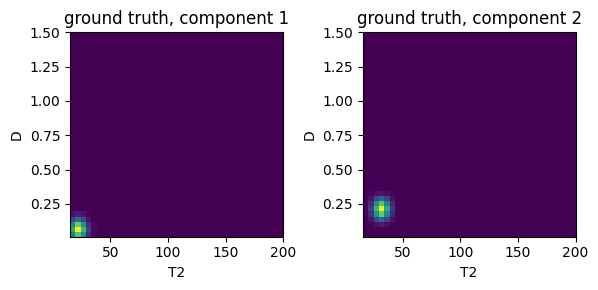

In [3]:
# Grid and fit settings: the same as the real-data fits (maria-tests-real-data_for_poster)
Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 15.0, 1.5, 200.0, 40, 40
K=2; # Number of compartments
V=40; # Number of voxels, as in each real-data region
R=10   # Rank for SVD

# acquisition of the real macaque data: 6 TEs x 8 b-values = 48 measurements
b_vals = np.array([0.0, 1000.0, 2500.0, 5000.0, 7500.0, 11100.0, 18100.0, 25000.0]) / 1000.0   # s/mm² -> ms/µm² (same units as D)
TE_vals = np.array([28.12, 33.0, 38.017, 45.0, 60.0, 78.0])   # ms

# two ground-truth compartments, placed at the peaks found in the real data
# (short T2 / slow diffusion like white matter, longer T2 / faster diffusion like grey matter)
D_means = [0.05, 0.2]
D_stds = [0.05, 0.05]
T2_means = [20, 29]
T2_stds = [5, 5]

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)

# A matrix from b_vals x TE_vals, b-major (b outer, TE inner), the same row order as the real-data fits
B_mesh, TE_mesh = np.meshgrid(b_vals, TE_vals, indexing="ij")
A = create_A_matrix_from_acquisition(D_grid, T2_grid, B_mesh.ravel(), TE_mesh.ravel())
U, s, Vmat = apply_SVD_to_A(A, R)

C_true = create_gaussian_compartments(D_grid, T2_grid, D_means, D_stds, T2_means, T2_stds)
W_true = rng.uniform(size=(K, V))
W_true /= W_true.sum(axis=0, keepdims=True)
M0_true = np.ones(V)*300

SNR = 50
sigma = M0_true/SNR # sigma needs to scale with M0
Y = create_signal(A, C_true, W_true, M0_true, sigma, rng)

show_canonical_spectra([('ground truth', C_true)])


iter 0: loss=981.4677, fit_err=109795.557852, sigma2=57.185186
iter 200: loss=968.3951, fit_err=106029.172202, sigma2=55.223527
iter 400: loss=968.3962, fit_err=106029.048358, sigma2=55.223463
iter 600: loss=968.4071, fit_err=106027.801993, sigma2=55.222814
iter 800: loss=968.3969, fit_err=106028.917137, sigma2=55.223394


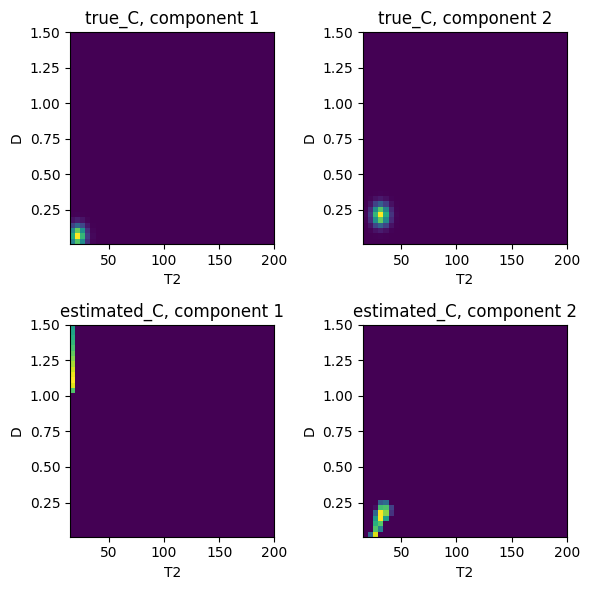

In [4]:
# Initialisation and fit: the same settings as the real-data fits
C0, *_ = define_initial_C_NNLS(Y,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2,min_fraction=0.01,return_diagnostics=True)
Csmall0 = project_C_to_C_small(C0,s,Vmat)
M0_init = initialize_M0_monoexponential(Y, b_vals, TE_vals)
W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

# noise level from the residual of the initial fit (no ground-truth sigma, as for real data)
sigma2_init = np.mean((Y - (U @ Csmall0 @ W0) * M0_init) ** 2)

W_est_p, M0_est_p, C_est_p, alpha_est_p, sigma2_est_p, *_ = run_constrained_optimisation(
    Y, U, s, Vmat, C0.copy(), M0_init, K=K, n_iter=1000,
    sigma2=sigma2_init, lam=1e-2, alpha=1.0, W=W0.copy(),
    update_W_flag=True, update_C_flag=True, update_M0_flag=True, update_sigma2_flag=True,
    m0_prior=M0_init, m0_prior_sigma=3, alpha_update_start=5,
    update_alpha_flag=True, weight_entropy=0.0,
    c_sparsity=0.0, c_smoothness=100.0, c_diversity=0.0, c_maxiter=100, nD=nD, nT2=nT2,
    verbose_every=200)

C_est_p, W_est_p = order_components(C_true, C_est_p, W_est_p, K)
show_canonical_spectra([('true_C', C_true), ('estimated_C', C_est_p)])


### Numbers


In [5]:
# Numbers to quote next to the poster figure
W_err = np.abs(W_true - W_est_p)
M0_rel = np.abs(M0_est_p - M0_true) / M0_true
Y_fit = (A @ C_est_p @ W_est_p) * M0_est_p

print(f"Setup: {V} voxels, {A.shape[0]} measurements per voxel, SNR {SNR}, {K} compartments")
print(f"Weights: mean abs error {W_err.mean():.3f}, max {W_err.max():.3f}, correlation r = {np.corrcoef(W_true.ravel(), W_est_p.ravel())[0, 1]:.3f}")
print(f"M0: mean relative error {100 * M0_rel.mean():.1f}%")
print(f"Signal: relative residual {100 * np.linalg.norm(Y - Y_fit) / np.linalg.norm(Y):.1f}%")

# Peak position of each compartment, true vs estimated
for k in range(K):
    iD_t, iT_t = np.unravel_index(np.argmax(C_true[:, k]), (nD, nT2))
    iD_e, iT_e = np.unravel_index(np.argmax(C_est_p[:, k]), (nD, nT2))
    print(f"Compartment {k + 1} peak: true (D = {D_vals[iD_t]:.2f}, T2 = {T2_vals[iT_t]:.0f} ms), "
          f"estimated (D = {D_vals[iD_e]:.2f}, T2 = {T2_vals[iT_e]:.0f} ms)")


Setup: 40 voxels, 48 measurements per voxel, SNR 50, 2 compartments
Weights: mean abs error 0.296, max 0.869, correlation r = 0.189
M0: mean relative error 16.8%
Signal: relative residual 19.9%
Compartment 1 peak: true (D = 0.05, T2 = 20 ms), estimated (D = 1.12, T2 = 15 ms)
Compartment 2 peak: true (D = 0.20, T2 = 29 ms), estimated (D = 0.12, T2 = 29 ms)
